### Imports

In [1]:
# Imports
import torch
import os
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM
# some additional functions
import SIGSOM.sigsom.utils.helpers2 as helper_functions

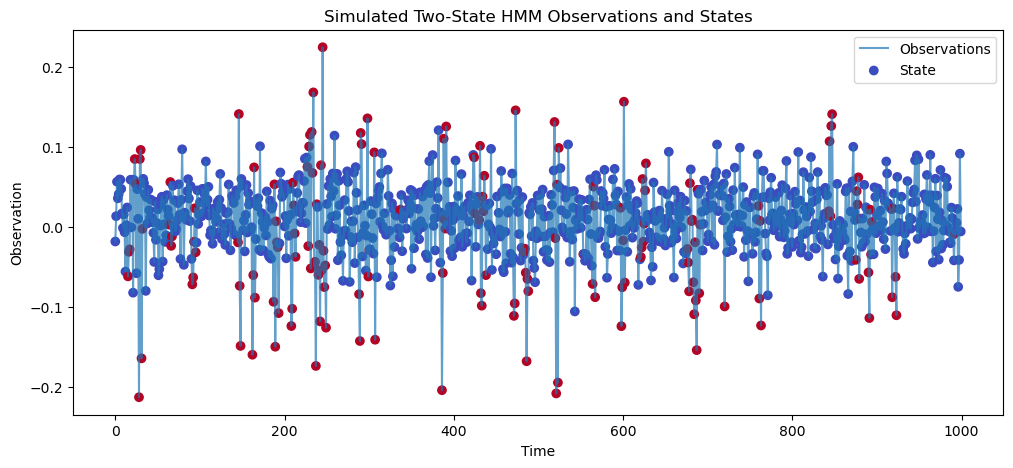

In [2]:
import numpy as np

def simulate_hmm(n_samples, mu, sigma, transition_matrix, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize state sequence
    states = np.zeros(n_samples, dtype=int)
    observations = np.zeros(n_samples)
    
    # Initial state
    states[0] = np.random.choice([0, 1])  # Assuming equal probability for start
    
    for t in range(1, n_samples):
        # Transition to next state
        states[t] = np.random.choice([0, 1], p=transition_matrix[states[t - 1]])
    
    # Generate observations based on state
    for t in range(n_samples):
        observations[t] = np.random.normal(mu[states[t]], sigma[states[t]])
    
    return states, observations

# Define Two-State HMM Parameters
mu_2state = [0.0123, -0.0157]
sigma_2state = [0.0347, 0.0778]
transition_2state = np.array([[0.9629, 0.0371], [0.2101, 0.7899]])

# Simulate two-state HMM
n_samples = 1000
states_2state, observations_2state = simulate_hmm(n_samples, mu_2state, sigma_2state, transition_2state, seed=42)

# Display first few samples
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(observations_2state, label="Observations", linestyle='-', alpha=0.7)
plt.scatter(range(n_samples), observations_2state, c=states_2state, cmap="coolwarm", marker="o", label="State")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.legend()
plt.title("Simulated Two-State HMM Observations and States")
plt.show()


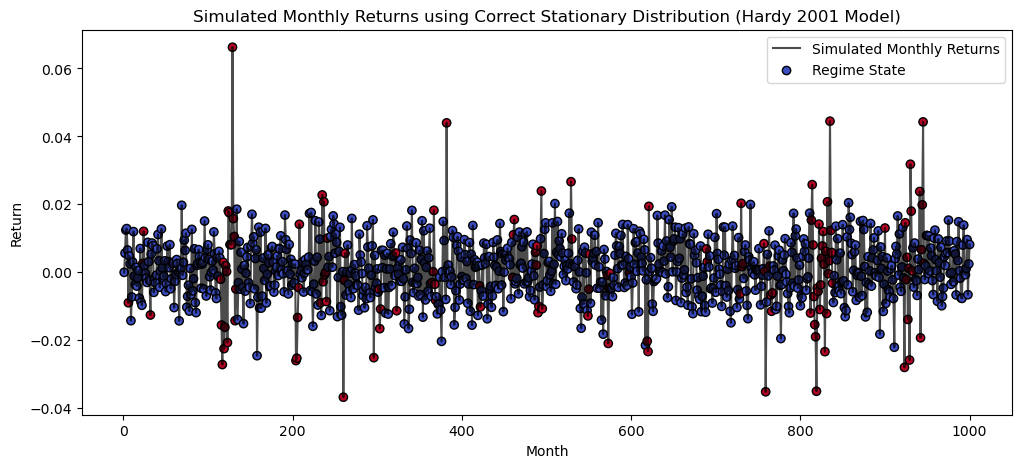

In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm  # Import expm from SciPy

# Set seed for reproducibility
np.random.seed(42)

# Define parameters for the continuous-time Markov regime-switching model (Hardy 2001)
mu1, sigma1 = 0.0123, 0.0347  # State 1 (Low volatility)
mu2, sigma2 = -0.0157, 0.0778  # State 2 (High volatility)
P = np.array([[0.9629, 0.0371], [0.2101, 0.7899]])  # Discrete Transition Matrix

# Compute stationary distribution using the correct formula
p12, p21 = P[0, 1], P[1, 0]
pi = np.array([p21 / (p12 + p21), p12 / (p12 + p21)])  # Invariant distribution

# Time settings
dt = 1/20  # Monthly time step
n_months = 1000  # 10 years of monthly data

# Initialize arrays to store results
states = np.zeros(n_months, dtype=int)
returns = np.zeros(n_months)

# Start in a state drawn from the stationary distribution
states[0] = np.random.choice([0, 1], p=pi)

# Simulate the Markov chain and returns
for t in range(1, n_months):
    states[t] = np.random.choice([0, 1], p=P[states[t-1], :])
    if states[t] == 0:
        returns[t] = mu1 * dt + sigma1 * np.sqrt(dt) * np.random.normal()
    else:
        returns[t] = mu2 * dt + sigma2 * np.sqrt(dt) * np.random.normal()

# Create a DataFrame for visualization
df_continuous = pd.DataFrame({"Month": np.arange(1, n_months + 1), "State": states, "Return": returns})

# Plot the simulated return series with regime coloring
plt.figure(figsize=(12, 5))
plt.plot(df_continuous["Month"], df_continuous["Return"], label="Simulated Monthly Returns", color="black", alpha=0.7)
plt.scatter(df_continuous["Month"], df_continuous["Return"], c=df_continuous["State"], cmap="coolwarm", label="Regime State", edgecolors="k")
plt.xlabel("Month")
plt.ylabel("Return")
plt.title("Simulated Monthly Returns using Correct Stationary Distribution (Hardy 2001 Model)")
plt.legend()
plt.show()


In [164]:
df_continuous["Return"]

0      0.000000
1      0.005641
2      0.012432
3      0.012868
4      0.006570
         ...   
995    0.001159
996    0.009630
997   -0.006580
998    0.002465
999    0.008182
Name: Return, Length: 1000, dtype: float64

In [3]:
import torch

# Reshape observations
data_5min_1 = observations_2state.reshape(-1, 1)

# Convert to PyTorch tensor
data_5min_1 = torch.tensor(data_5min_1, dtype=torch.float32)
def rolling_window1(x: torch.Tensor, window: int) -> torch.Tensor:
    N = x.shape[0] - window + 1  # Ensures overlapping windows with step size 1
    result = torch.empty((N, window, x.shape[1]), dtype=x.dtype, device=x.device)

    for i in range(N):
        result[i, :, :] = x[i:i+window, :]

    return result

# Use overlapping rolling window (stride=1 ensures overlap)
data_5min_1 = rolling_window1(data_5min_1, window=5)  # Overlapping

# # Normalize by subtracting the first value of each window
# data_5min_1 = data_5min_1 - data_5min_1[:, 0:1]
# data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)

# # Concatenate to form a multivariate path
# multivariate_path = torch.cat([data_5min_1], dim=2)

# # Split into training and test sets
# train_data = multivariate_path[:900]
# test_data = multivariate_path[900:]

# # Compute Min-Max scaling only on the training set
# data_min = train_data.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]
# data_max = train_data.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]

# # Apply Min-Max scaling using training statistics
# train_scaled = (train_data - data_min) / (data_max - data_min)
# test_scaled = (test_data - data_min) / (data_max - data_min)  # Use train min/max!

# # Check the range of the scaled data
# print(train_scaled.min().item(), train_scaled.max().item())  # Should be ~0 to 1
# print(test_scaled.min().item(), test_scaled.max().item())    # May have some out-of-range values

# # Combine back for later use if needed
# scaled_data = torch.cat([train_scaled, test_scaled], dim=0)

# print(scaled_data.shape)


In [4]:
import torch
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.signature, {"depth": 2, "basepoint": False})]

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        # print("aug",np.isnan(aug).any())
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)
            # print("signature",np.isnan(sig).any())
            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[2]  # Number of input dimensions (e.g., 6)
            rescaled_sig = st.rescale_signature_by_factorial("log", sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(data_5min_1[:], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_signature"].shape)

torch.Size([996, 3])


# Save Signatures for Autoencoding

In [5]:
# vif_cleaned_result = st.remove_vif(results1["lead_lag_transform_log_singature"], threshold=4)
# vif_cleaned_result.shape

### FITTING SOM

In [171]:
import numpy as np
import pandas as pd

def compute_hmm_features(y: np.ndarray, window: int = 10):
    """
    Compute HMM estimation features from a given time series.
    
    Parameters:
    - y: np.ndarray, shape (T,), the time series observations.
    - window: int, the window length for local statistics.
    
    Returns:
    - features: pd.DataFrame, extracted feature set.
    """
    T = len(y)
    half_w = (window - 1) // 2

    # Ensure enough data points for windowing
    if T < window:
        raise ValueError("Time series is too short for the chosen window size.")

    # Compute features
    obs = y[half_w:-half_w]  # Observation yt
    left_abs_change = np.abs(y[half_w:-half_w] - y[half_w-1:-half_w-1])  # |yt - yt-1|
    right_abs_change = np.abs(y[half_w+1:-half_w+1] - y[half_w:-half_w])  # |yt+1 - yt|

    # Local statistics
    centered_mean = np.array([np.mean(y[i-half_w:i+half_w+1]) for i in range(half_w, T-half_w)])
    centered_std = np.array([np.std(y[i-half_w:i+half_w+1]) for i in range(half_w, T-half_w)])
    
    left_mean = np.array([np.mean(y[i-half_w:i+1]) for i in range(half_w, T-half_w)])
    left_std = np.array([np.std(y[i-half_w:i+1]) for i in range(half_w, T-half_w)])
    
    right_mean = np.array([np.mean(y[i:i+half_w+1]) for i in range(half_w, T-half_w)])
    right_std = np.array([np.std(y[i:i+half_w+1]) for i in range(half_w, T-half_w)])

    # Create DataFrame
    feature_df = pd.DataFrame({
        "Observation": obs,
        "Left Abs Change": left_abs_change,
        "Right Abs Change": right_abs_change,
        "Centered Mean": centered_mean,
        "Centered Std": centered_std,
        "Left Mean": left_mean,
        "Left Std": left_std,
        "Right Mean": right_mean,
        "Right Std": right_std
    })

    return feature_df

# Example usage:
# Generate some dummy time series data
np.random.seed(42)
observations_2state = np.random.randn(1000)  # Replace with your actual time series

# Compute features
# hmm_features_df = compute_hmm_features(observations_2state, window=5)
hmm_features_df = compute_hmm_features(df_continuous["Return"].values, window=5)

# Display the first few rows
print(hmm_features_df.head())


   Observation  Left Abs Change  Right Abs Change  Centered Mean  Centered Std  Left Mean  Left Std  Right Mean  Right Std
0     0.012432         0.006792          0.000436       0.007502      0.004769   0.006024  0.005083    0.010623   0.002872
1     0.012868         0.000436          0.006299       0.005712      0.007901   0.010314  0.003309    0.003495   0.009170
2     0.006570         0.006299          0.015522       0.005549      0.007910   0.010623  0.002872    0.000814   0.006942
3    -0.008952         0.015522          0.013777       0.003561      0.007141   0.003495  0.009170   -0.000545   0.006021
4     0.004825         0.013777          0.002332      -0.001859      0.008222   0.000814  0.006942   -0.002304   0.008487


### SOM Jump

In [195]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import numpy as np
from SIGSOM.sigsom.som.som_jump import SOM  # Import the new SOM with Jump Penalty
# from SIGSOM.sigsom.som.som import SOM  # Import the new SOM with Jump Penalty

from datetime import datetime

# Initialize variables for tracking the best model



# Step 1: Preprocess the Data
# scaler = PowerTransformer(method='yeo-johnson', standardize=True)
# data_scaled = scaler.fit_transform(results1["lead_lag_transform_signature"][:600, :])  

scaler = MinMaxScaler(feature_range=(-1, 1))
train_matrix = scaler.fit_transform(hmm_features_df.values)
train_matrix1 = torch.tensor(train_matrix, dtype=torch.float32)
# params = SOMParams(map_size=(2, 1),Tmax=6,Tmin=.01,batch_size = 512,iterations = 500, input_dims=train_matrix1.shape[1], lr=0.05, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))

# Step 2: Define SOM Parameters
params = SOMParams(
    map_size=(2, 1),
    Tmax=3,
    Tmin=.1,
    batch_size=512,
    iterations=5000,
    input_dims=train_matrix1.shape[1],
    lr=0.01,
    jump_penalty_epochs=10,  # Every 10 epochs, apply BMU smoothing
    lambda_jump=0.2,  # Strength of jump penalty
    decay="exponential",
    dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"
)

# Step 3: Initialize and Train the SOM with Jump Penalty
som_model = SOM(logger=logger, params=params)
som_model.initialize(train_matrix1)
som_model.fit(X_train=train_matrix1)


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
2025-02-24 10:52:34,971        som_jump INFO     MainThread   MainProcess Using jump penalty with 10 iterations
2025-02-24 10:52:35,137        som_jump INFO     MainThread   MainProcess Applying BMU smoothing at epoch 10
2025-02-24 10:52:35,149        som_jump INFO     MainThread   MainProcess Smoothed BMU sequence computed.
2025-02-24 10:52:35,303        som_jump INFO     MainThread   MainProcess Applying BMU smoothing at epoch 20
2025-02-24 10:52:35,317        som_jump INFO     MainThread   MainProcess Smoothed BMU sequence computed.
2025-02-24 10:52:35,449        som_jump INFO     MainThread   MainProcess Applying BMU smoothing at epoch 30
2025-02-24 10:52:35,460        som_jump INFO     MainThread

Training with jump penalty completed.


In [266]:
a =som_model.predict(train_matrix1)
# a = som_model.refine_bmu_sequence(a, train_matrix1,lambda_jump=0.1)

In [267]:
states_2state

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

In [268]:
a = abs(a-1)
a

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,

In [269]:
abs(a-states_2state[4:]).sum()

tensor(708)

In [12]:
import numpy as np
import pandas as pd
from hmmlearn import hmm

# Convert feature DataFrame to NumPy array
X = hmm_features_df#.drop(columns=["Cluster"]).values  # Drop cluster column if it exists

# Define HMM model with regularization
n_components = 2  # Two hidden states
hmm_model = hmm.GaussianHMM(
    n_components=n_components, 
    covariance_type="full", 
    n_iter=1000, 
    tol=1e-4,  # Convergence tolerance
    random_state=42
)

# Set initial parameters (MLE initialization)
hmm_model.startprob_ = np.array([1.0, 0.0])  # Start in state 1 with probability 1
hmm_model.transmat_ = np.array([[0.9, 0.1], [0.1, 0.9]])  # High persistence assumption
hmm_model.means_ = np.array([[0.0], [0.0]])  # Initial means set to 0
hmm_model.covars_ = np.array([[[0.01]], [[0.01]]])  # Small initial variances

# Fit HMM to the feature data
hmm_model.fit(X)

# Predict hidden states
hidden_states = hmm_model.predict(X)

# Add hidden states to the DataFrame
hmm_features_df["HMM State"] = hidden_states

# Display the first few rows
print(hmm_features_df.head())


Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'


Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Model is not converging.  Current: 2491.442874250969 is not greater than 12034.931704902696. Delta is -9543.488830651728


   Observation  Left Abs Change  Right Abs Change  Centered Mean  \
0     0.647689         0.785953          0.875341       0.459003   
1     1.523030         0.875341          1.757183       0.312833   
2    -0.234153         1.757183          0.000016       0.656328   
3    -0.234137         0.000016          1.813350       0.680277   
4     1.579213         1.813350          0.811778       0.281777   

   Centered Std  Left Mean  Left Std  Right Mean  Right Std  HMM State  
0      0.633462   0.335379  0.340541    0.645522   0.717369          0  
1      0.689719   0.677485  0.678548    0.351580   0.828340          0  
2      0.798605   0.645522  0.717369    0.370307   0.854825          0  
3      0.799781   0.351580  0.828340    0.704170   0.741647          0  
4      0.776651   0.370307  0.854825    0.625724   0.842354          0  


In [270]:
a

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,

In [271]:
from sklearn.metrics import accuracy_score

# Compute balanced accuracy
balanced_acc = accuracy_score(a, states_2state[4:])

# Print results
print(f"Balanced Accuracy: {balanced_acc:.2%}")

Balanced Accuracy: 28.92%


In [272]:
from sklearn.metrics import balanced_accuracy_score

# Compute balanced accuracy
balanced_acc = balanced_accuracy_score(a, states_2state[4:])

# Print results
print(f"Balanced Accuracy: {balanced_acc:.2%}")

Balanced Accuracy: 49.86%


In [210]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(states_2state[4:], jm.labels_.values)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[508 326]
 [109  53]]


In [230]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from jumpmodels.jumpmodels.utils import filter_date_range        # useful helpers
from jumpmodels.jumpmodels.jump import JumpModel                 # class of JM & CJM
from jumpmodels.jumpmodels.sparse_jump import SparseJumpModel 



# set the jump penalty
jump_penalty=0
# initlalize the JM instance
jm = JumpModel(n_components=2, jump_penalty=jump_penalty, cont=False, )

jm.fit(hmm_features_df.values, sort_by="cumret")

JumpModel(jump_penalty=0)

In [233]:
jm.labels_

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
import SIGSOM.sigsom.utils.helpers2 as helper_functions

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
# Assuming `vif_cleaned_result`, scalers, and gsomm are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# # Step 3: Get predictions and quantization error
# b = som_model.predict(test_matrix)  # Replace 'gsomm.predict' with your method
# b = som_model.refine_bmu_sequence(b, test_matrix,lambda_jump=0.2)
# test_preds = np.array(b).flatten()
# initial_preds_rep = np.repeat(test_preds, 10*96)
# initial_preds_rep.shape

# # Assuming btc data is already extracted
# btc = resampled_data1.values[96000:, 0]
# output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\bitcoin.png"

# helper_functions.plot_btc_price(predictions=initial_preds_rep, btc_prices=btc, output_path=output_path, title='BTC Price Colored by Predictions')

In [ ]:
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(test_matrix, lambda_jump=.5)
z = som_model.refine_bmu_sequence(predicted_bmus, test_matrix, lambda_jump=0.1)
z.shape

torch.Size([92])

In [ ]:
# Assuming 'som_model' is your trained SOM
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(test_matrix, lambda_jump=.5)

print("Predicted BMUs:", predicted_bmus)
# print("Arrival Costs:", arrival_costs)

predicted_bmus = np.array(predicted_bmus).flatten()
predicted_bmus = np.repeat(predicted_bmus, 10*96)
predicted_bmus.shape

# Assuming btc data is already extracted
btc = resampled_data1.values[96000:, 0]


Predicted BMUs: tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])


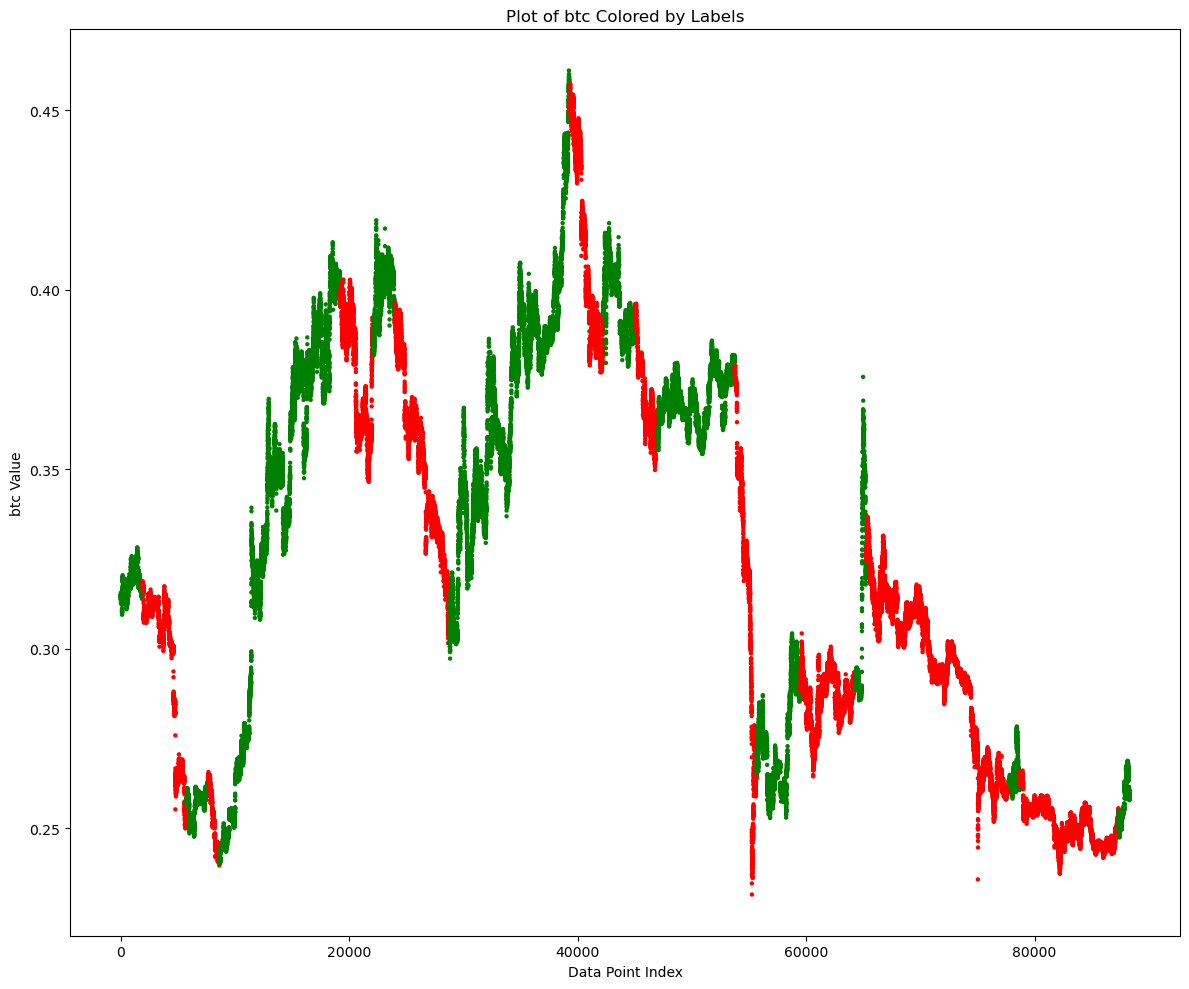

In [ ]:
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(88320), btc[:88320],
               c=predicted_bmus, cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
test_matrix.shape

torch.Size([92, 8])

In [ ]:
X = torch.rand(100, 8)  # Random input with 100 time steps
predicted_bmus, arrival_costs = som_model.greedy_online_prediction(X, lambda_jump=10000000000000)

print(predicted_bmus.shape)  # Expected: (100,)
print(arrival_costs.shape)   # Expected: (100, num_units)

torch.Size([100])
torch.Size([100, 2])


In [ ]:
predicted_bmus

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])